<a href="https://colab.research.google.com/github/WizardsugarGG/MINERIA-DE-DATOS/blob/main/DBSCAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

In [5]:
#1 Datos de ejemplo (coordenadas de ciudades)
data = {
    'Ciudad': ['A', 'B', 'C', 'D', 'E','F'],
    "x": [1.0,1.5,10.0,1.1,0.8,1.4,],
    "Y": [1.1,1.2,10.0,0.9,1.3,0.8],
    "poblacion": [500,50,10,400,300,200]
}

df = pd.DataFrame(data)

In [8]:

#2 crear una figura con tamaño personalizado
coords = df [["x","Y"]].values
coords_normalized = StandardScaler().fit_transform(coords) #evitar escalas

#3 aplicar DBSCAN
# Instantiate DBSCAN with example parameters (eps and min_samples might need tuning)
dbsc = DBSCAN(eps=0.5, min_samples=3)
dbscan = dbsc.fit_predict(coords_normalized)

#4 asignar cluster al dataFrame
df["cluster"] = dbscan
print(df.head())

  Ciudad     x     Y  poblacion  cluster
0      A   1.0   1.1        500        0
1      B   1.5   1.2         50        0
2      C  10.0  10.0         10       -1
3      D   1.1   0.9        400        0
4      E   0.8   1.3        300        0


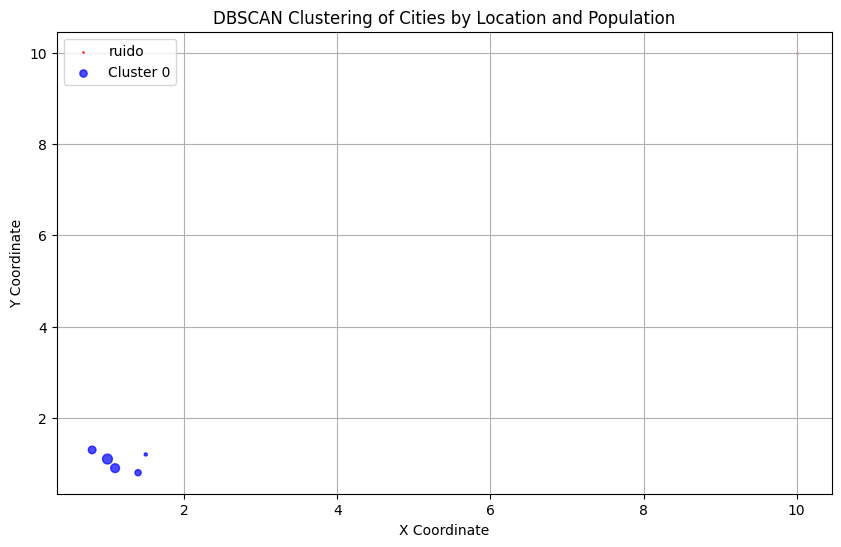

In [11]:
#crear una figura con tamaño personalizado
plt.figure(figsize=(10, 6))

#definir colore para cada cluster (azul para cluster 0 ,rojo para ruido)
colors = {0:"blue",-1: "red"}

#insert sobre cada grupo de puntos segun su cluster
for cluster, group in df.groupby("cluster"):
  plt.scatter(
      group["x"],
      group["Y"],
      color = colors[cluster],
      alpha = 0.7, # Adjusted alpha to a single value
      label = f"Cluster {cluster}" if cluster != -1 else "ruido",
      s=group["poblacion"]/10
  )
# Add plot title, labels, and legend for better visualization
plt.title("DBSCAN Clustering of Cities by Location and Population")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.legend()
plt.grid(True)
plt.show()

ejercio 2


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

In [15]:
df = pd.read_csv('ejercicio_1_zonas_entrega.csv')

# Mostrar primeras filas
print(df.head())

# Seleccionar columnas necesarias. Using 'X' and 'Y' as they are present in the dataframe.
datos = df[['X', 'Y']]

print("\nDatos originales:")
print(datos.head())

  Punto    X    Y
0    P1  1.0  1.0
1    P2  1.2  1.3
2    P3  0.8  0.9
3    P4  1.1  1.0
4    P5  5.0  5.0

Datos originales:
     X    Y
0  1.0  1.0
1  1.2  1.3
2  0.8  0.9
3  1.1  1.0
4  5.0  5.0


In [16]:
# 2. Escalar datos con StandardScaler
scaler = StandardScaler()

datos_escalados = scaler.fit_transform(datos)

print("\nDatos escalados:")
print(datos_escalados[:5])


Datos escalados:
[[-1.22668669 -1.18385068]
 [-1.16065387 -1.08434599]
 [-1.29271952 -1.21701891]
 [-1.19367028 -1.18385068]
 [ 0.09396979  0.14287853]]


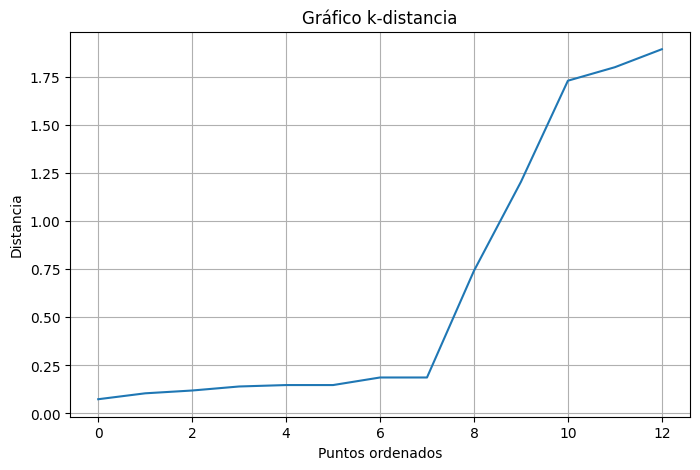

In [17]:
# 3. Método k-distancia para elegir eps
# Generalmente min_samples = 4 o 5
k = 4

neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(datos_escalados)

distancias, indices = neighbors_fit.kneighbors(datos_escalados)

# Ordenar distancias
distancias = np.sort(distancias[:, k-1])

# Graficar k-distancia
plt.figure(figsize=(8,5))
plt.plot(distancias)

plt.title('Gráfico k-distancia')
plt.xlabel('Puntos ordenados')
plt.ylabel('Distancia')

plt.grid(True)
plt.show()

In [18]:
eps_valor = 0.5
# 4. Aplicar DBSCAN

dbscan = DBSCAN(
    eps=eps_valor,
    min_samples=4
)

clusters = dbscan.fit_predict(datos_escalados)

# Agregar columna Cluster
df['Cluster'] = clusters

print("\nResultado con clusters:")
print(df.head())



Resultado con clusters:
  Punto    X    Y  Cluster
0    P1  1.0  1.0        0
1    P2  1.2  1.3        0
2    P3  0.8  0.9        0
3    P4  1.1  1.0        0
4    P5  5.0  5.0        1


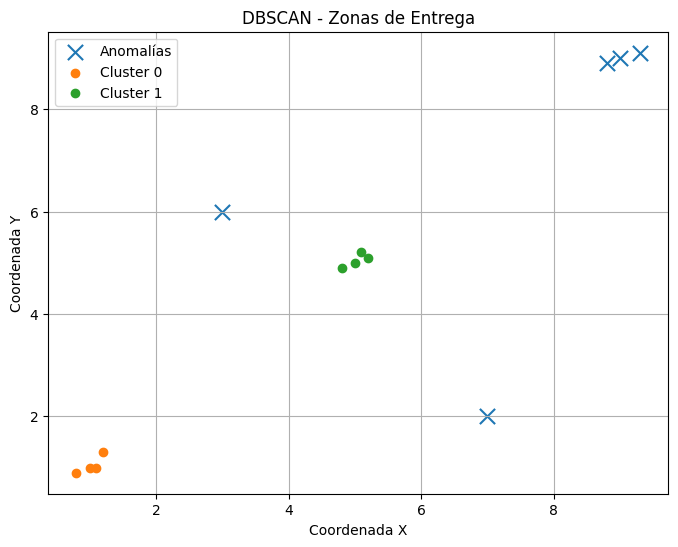

In [20]:
# 5. Graficar clusters y anomalías
plt.figure(figsize=(8,6))

# Obtener clusters únicos
clusters_unicos = np.unique(clusters)

for cluster in clusters_unicos:

    # Filtrar puntos del cluster
    puntos = df[df['Cluster'] == cluster]

    # Cluster -1 = anomalías
    if cluster == -1:
        plt.scatter(
            puntos['X'],  # Changed from 'Temperatura' to 'X'
            puntos['Y'],  # Changed from 'Humedad' to 'Y'
            s=120,
            marker='x',
            label='Anomalías'
        )

    else:
        plt.scatter(
            puntos['X'],  # Changed from 'Temperatura' to 'X'
            puntos['Y'],  # Changed from 'Humedad' to 'Y'
            label=f'Cluster {cluster}'
        )

plt.xlabel('Coordenada X') # Updated label
plt.ylabel('Coordenada Y') # Updated label

plt.title('DBSCAN - Zonas de Entrega') # Updated title

plt.legend()
plt.grid(True)

plt.show()

In [21]:
print("\nCantidad de elementos por cluster:")
print(df['Cluster'].value_counts())

# ==========================================
# Mostrar anomalías detectadas
# ==========================================

anomalias = df[df['Cluster'] == -1]

print("\nAnomalías detectadas:")
print(anomalias)


Cantidad de elementos por cluster:
Cluster
-1    5
 0    4
 1    4
Name: count, dtype: int64

Anomalías detectadas:
   Punto    X    Y  Cluster
8     P9  9.0  9.0       -1
9    P10  9.3  9.1       -1
10   P11  8.8  8.9       -1
11   P12  3.0  6.0       -1
12   P13  7.0  2.0       -1


DBSCAN es mejor para este problema porque:

Detecta condiciones anómalas automáticamente.
Se basa en densidad.
Identifica ruido real en sensores ambientales.
K-Means solo agrupa, pero no detecta anomalías explícitamente.